In [1]:
# =============================================================================
# 1. IMPORTS AND SETUP
# =============================================================================
%load_ext autoreload
%autoreload 2
import os
import sys
import pathlib
import re
import gc
import yaml
import warnings
import time
from multiprocessing import Pool, cpu_count

# Suppress warnings
warnings.filterwarnings("ignore")

# --- Environment and JAX Configuration ---
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import jax
from jax.lib import xla_bridge
import jax.numpy as jnp
import jax_cosmo.background as bkgrd

platform = xla_bridge.get_backend().platform
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
print(f"JAX backend: {platform}, Total devices: {jax.device_count()}, Local devices: {jax.local_device_count()}")

import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()

# --- Library Imports ---
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import h5py as h5
import healpy as hp
from tqdm import tqdm
import pickle as pk

# --- Matplotlib Configuration ---
plt.rcParams['text.usetex'] = True
# To use Palatino font (if installed):
# plt.rcParams['font.family'] = 'Palatino'

# --- Add Project-Specific Paths ---
curr_path = pathlib.Path().absolute()
# Assuming the script is in a subdirectory like 'notebooks' or 'scripts'
# Adjust the path if the project structure is different.
project_base = curr_path.parents[1] 
abs_path_data = project_base / "data"
abs_path_src = project_base / "src"
abs_path_results = project_base / "results"

for path in [curr_path, abs_path_data, abs_path_src, abs_path_results]:
    sys.path.append(str(path))

# --- Import Custom Modules ---
from godmax.get_radial_profiles import Profiles
from godmax.get_sim_maps import setup_sim_map, get_sim_map
import helpers.constants as constants
from godmax.get_B12_profile import Battaglia_12_16
import helpers.constants as constants

# =============================================================================
# 2. HELPER FUNCTIONS
# =============================================================================

def split_array_power_ratio(arr, num_parts, power_val=0.5):
    """Splits an array into parts with sizes proportional to j^power_val."""
    n_total = arr.shape[0]
    j_values = np.arange(1, num_parts + 1)
    weights = j_values**power_val
    sum_of_weights = np.sum(weights)
    ideal_sizes = (n_total / sum_of_weights) * weights
    
    int_sizes = np.floor(ideal_sizes).astype(int)
    remainder = n_total - np.sum(int_sizes)
    
    # Distribute remainder based on fractional parts
    fractional_parts = ideal_sizes - int_sizes
    indices_to_increment = np.argsort(fractional_parts)[-remainder:]
    int_sizes[indices_to_increment] += 1
    
    split_indices = np.cumsum(int_sizes)[:-1]
    return np.split(arr, split_indices)

def read_yaml(file_path):
    """Reads a YAML file and returns its content."""
    with open(file_path, 'r') as file:
        return yaml.safe_load(file)

def generate_dicts(data):
    """Extracts parameter dictionaries from the main data dictionary."""
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

# --- Functions for Parallel Halo Processing ---

def process_halo(args):
    """Finds pixels near a single halo."""
    jhalo, ra_all_np, dec_all_np, halo_cat_R200c_np, halo_cat_DV_np, max_paint_R200c_factor, nside_local, pixel_dtype = args
    
    vec = hp.ang2vec(ra_all_np[jhalo], dec_all_np[jhalo], lonlat=True)
    # Angle subtended by the painting radius
    nearby_angle = max_paint_R200c_factor * halo_cat_R200c_np[jhalo] / halo_cat_DV_np[jhalo]
    nearby_pix = hp.query_disc(nside_local, vec, nearby_angle)
    
    if len(nearby_pix) == 0:
        return None
    
    nearby_pix = np.asarray(nearby_pix, dtype=pixel_dtype)
    nearby_ra, nearby_dec = hp.pix2ang(nside_local, nearby_pix, lonlat=True)
    
    # Haversine formula to calculate angular separation
    ra1, dec1 = np.radians(ra_all_np[jhalo]), np.radians(dec_all_np[jhalo])
    ra2, dec2 = np.radians(nearby_ra), np.radians(nearby_dec)
    
    a = np.sin((dec1 - dec2)/2)**2 + np.cos(dec1) * np.cos(dec2) * np.sin((ra1 - ra2)/2)**2
    theta = 2 * np.arcsin(np.sqrt(a))
    
    # Projected distance in Mpc
    distances = (halo_cat_DV_np[jhalo] * theta).astype(np.float32)
    
    return (nearby_pix, distances, jhalo, len(nearby_pix))

def concatenate_batch_results(results, M_all_chunk, z_all_chunk, vlos_all_chunk, halo_cat_DV_np, halo_cat_R200c_np, max_paint_R200c_factor, pixel_dtype):
    """Concatenates results from a single batch of parallel processing."""
    if not results:
        return None
        
    lengths = np.array([res[3] for res in results], dtype=np.int32)
    total_length = lengths.sum()
    
    # Pre-allocate arrays for efficiency
    nearby_pix_all = np.empty(total_length, dtype=pixel_dtype)
    distances_pix_all = np.empty(total_length, dtype=np.float32)
    halo_indices = np.empty(total_length, dtype=np.int32)
    
    end_indices = np.cumsum(lengths)
    start_indices = np.concatenate([[0], end_indices[:-1]])
    
    for i, (start, end, res) in enumerate(zip(start_indices, end_indices, results)):
        nearby_pix_all[start:end] = res[0]
        distances_pix_all[start:end] = res[1]
        halo_indices[start:end] = res[2]
    
    original_halo_indices = np.array([res[2] for res in results], dtype=np.int32)
    
    # Map pixel-level properties back from halo-level properties
    logM_ind_all = np.log(M_all_chunk[halo_indices]).astype(np.float32)
    z_ind_all = z_all_chunk[halo_indices].astype(np.float32)
    vlos_ind_all = vlos_all_chunk[halo_indices].astype(np.float32)
    
    # Map halo-level properties
    ang_distance_all = halo_cat_DV_np[original_halo_indices].astype(np.float32)
    rp_max_all = (max_paint_R200c_factor * halo_cat_R200c_np[original_halo_indices]).astype(np.float32)
    
    return (nearby_pix_all, distances_pix_all, start_indices, end_indices, 
            logM_ind_all, z_ind_all, vlos_ind_all, ang_distance_all, rp_max_all)

def final_concatenate_batches(all_results, pixel_dtype):
    """Final concatenation of results from all batches."""
    total_pix = sum(len(res[0]) for res in all_results)
    total_halos = sum(len(res[2]) for res in all_results)
    
    # Pre-allocate final arrays
    final_nearby_pix = np.empty(total_pix, dtype=pixel_dtype)
    final_distances = np.empty(total_pix, dtype=np.float32)
    final_logM = np.empty(total_pix, dtype=np.float32)
    final_z = np.empty(total_pix, dtype=np.float32)
    final_vlos = np.empty(total_pix, dtype=np.float32)
    final_start_ind = np.empty(total_halos, dtype=np.int32)
    final_end_ind = np.empty(total_halos, dtype=np.int32)
    final_ang_dist = np.empty(total_halos, dtype=np.float32)
    final_rp_max = np.empty(total_halos, dtype=np.float32)
    
    pix_offset, halo_offset = 0, 0
    for result in all_results:
        n_pix_batch = len(result[0])
        n_halo_batch = len(result[2])
        
        # Unpack batch results
        nearby_pix_b, dist_b, start_b, end_b, logM_b, z_b, vlos_b, ang_dist_b, rp_max_b = result
        
        # Fill pixel-level arrays
        final_nearby_pix[pix_offset : pix_offset + n_pix_batch] = nearby_pix_b
        final_distances[pix_offset : pix_offset + n_pix_batch] = dist_b
        final_logM[pix_offset : pix_offset + n_pix_batch] = logM_b
        final_z[pix_offset : pix_offset + n_pix_batch] = z_b
        final_vlos[pix_offset : pix_offset + n_pix_batch] = vlos_b
        
        # Fill halo-level arrays, adjusting indices with the offset
        final_start_ind[halo_offset : halo_offset + n_halo_batch] = start_b + pix_offset
        final_end_ind[halo_offset : halo_offset + n_halo_batch] = end_b + pix_offset
        final_ang_dist[halo_offset : halo_offset + n_halo_batch] = ang_dist_b
        final_rp_max[halo_offset : halo_offset + n_halo_batch] = rp_max_b
        
        pix_offset += n_pix_batch
        halo_offset += n_halo_batch
        
    return (final_nearby_pix, final_distances, final_start_ind, final_end_ind,
            final_logM, final_z, final_vlos, final_ang_dist, final_rp_max)

def process_halos_in_batches(M_all_chunk, ra_all_chunk, dec_all_chunk, z_all_chunk, vlos_all_chunk, 
                             halo_cat_R200c, halo_cat_DA, max_paint_R200c_factor, nside, batch_size=1000):
    """Manages the parallel processing of halos in manageable batches."""
    pixel_dtype = np.int32 if nside <= 8192 else np.int64
    
    ra_all_np = np.clip(np.array(ra_all_chunk, dtype=np.float32), 0.01, 359.99)
    dec_all_np = np.clip(np.array(dec_all_chunk, dtype=np.float32), -89.99, 89.99)
    halo_cat_R200c_np = np.array(halo_cat_R200c, dtype=np.float32)
    halo_cat_DV_np = np.array(halo_cat_DA, dtype=np.float32)
    
    n_halos = len(z_all_chunk)
    all_results = []
    
    with Pool(cpu_count()) as pool:
        for batch_start in range(0, n_halos, batch_size):
            batch_end = min(batch_start + batch_size, n_halos)
            print(f"Processing halo batch {batch_start//batch_size + 1}/{(n_halos - 1)//batch_size + 1}...")
            
            # Create arguments for each halo in the batch
            batch_args = [(jhalo, ra_all_np, dec_all_np, halo_cat_R200c_np, halo_cat_DV_np, 
                           max_paint_R200c_factor, nside, pixel_dtype) for jhalo in range(batch_start, batch_end)]
            
            # Map processing to the pool
            batch_results = pool.map(process_halo, batch_args)
            batch_results = [r for r in batch_results if r is not None]
            
            if batch_results:
                # Concatenate results from the current batch
                batch_data = concatenate_batch_results(batch_results, M_all_chunk, z_all_chunk, vlos_all_chunk, 
                                                       halo_cat_DV_np, halo_cat_R200c_np, max_paint_R200c_factor, pixel_dtype)
                if batch_data is not None:
                    all_results.append(batch_data)
            
            del batch_results, batch_args
            gc.collect()
    
    if not all_results:
        return None
        
    return final_concatenate_batches(all_results, pixel_dtype)




JAX backend: gpu, Total devices: 1, Local devices: 1


In [ ]:
# --- Timing Flag ---
PROFILE_TIMING = True

if PROFILE_TIMING:
    script_start_time = time.perf_counter()
    
# --- Analysis Parameters ---
nside = 1024
jdevice = 0
Ndevices = 1

# --- Load Configuration and Initialize Models ---
if PROFILE_TIMING:
    setup_start_time = time.perf_counter()

yaml_file_path = '/mnt/home/spandey/ceph/GODMAX/param_files/params_default.yaml'
data = read_yaml(yaml_file_path)
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(data)

# Override halo parameters for this analysis
halo_params_dict.update({
    'rmin': 0.0001, 'rmax': 10.0, 'nr': 48,
    'zmin': 0.001, 'zmax': 3.1, 'nz': 59,
    'lg10_Mmin': 12.0, 'lg10_Mmax': 16.2, 'nM': 128
})
# cosmo_params_dict = {'w0': -1.0, 'flat': True, 'H0': 67.74, 'Om0': 0.3089, 
#                         'Ob0': 0.0486, 'sigma8': 0.8159, 'ns': 0.9667}

# Prof_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)

cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 67.74, 'Om0': 0.3089, 'Ob0': 0.0486, 'sigma8':0.8159 ,'ns': 0.9667}
Prof_test = Battaglia_12_16(sim_params_dict={'cosmo':cosmo_params_dict, 'init_power':True}, halo_params_dict=halo_params_dict)

mock_params_dict_setup = {}
mock_params_dict_setup['nside'] = nside
mock_params_dict_setup['get_ymap'] = True
mock_params_dict_setup['get_kSZmap'] = False
mock_params_dict_setup['get_taumap'] = False
mock_params_dict_setup['get_kappamap'] = False
mock_params_dict_setup['get_galmap'] = False
mock_params_dict_setup['smooth_profiles'] = True
Prof_test = setup_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict_setup, Profiles_obj=Prof_test)

import h5py as h5
chi2z_interp = interpolate.interp1d(np.log(Prof_test.chi_array), Prof_test.z_array, fill_value="extrapolate")

if PROFILE_TIMING:
    setup_end_time = time.perf_counter()
    print(f"\n[PROFILE] Initial setup time: {setup_end_time - setup_start_time:.2f} seconds")

# --- Identify Redshift Slices to Process ---
fname = '/mnt/ceph/users/abayer/fastpm/halfdome/stampede2_3750Mpch_6144cube/final_res/halos/lightcone_100.hdf5'
with h5.File(fname, 'r') as f:
    # print(f.keys())
    M200c_all = f['halo_mass_m200c'][:]
    z_all = f['redshift'][:]
    pos = f['Position'][:]
    v_all = f['Velocity'][:]

ra_all, dec_all = hp.vec2ang(pos, lonlat=True)

# get the line of sight velocity:
vlos_all = np.sum(v_all * hp.ang2vec(ra_all, dec_all, lonlat=True), axis=1)

zmax = 1.5
indsel = np.where((z_all>0.001) & (z_all<zmax) & (M200c_all<4e16) & (M200c_all>(10**13.0)))[0]

argsort = np.flip(np.argsort(M200c_all[indsel]))
Nsel = (len(argsort) // Ndevices) * Ndevices
argsort = argsort[:Nsel]

argsort_split = split_array_power_ratio(argsort, Ndevices)
argsort_here = argsort_split[jdevice]
final_indices = indsel[argsort_here]

ra_all, dec_all, z_all, M200c_all, vlos_all = (
    ra_all[final_indices], dec_all[final_indices], z_all[final_indices], 
    M200c_all[final_indices], vlos_all[final_indices]
)


print(f"Number of halos for this device: {len(M200c_all)}")
print(f"Mean log(M200c): {np.mean(np.log10(M200c_all)):.2f}, Mean z: {np.mean(z_all):.2f}")

# --- Chunking and Map Generation ---
nh_max_map = {8192: 4e3, 4096: 5e4, 2048: 5e5, 1024: 5e6}
nh_max = nh_max_map.get(nside, 1e5) # Default if nside not in map
nsel = len(M200c_all)
num_chunks = int(np.ceil(nsel / nh_max)) if nsel > nh_max else 1

map_rhom, map_ymap, map_ksz, map_tau = (np.zeros(12 * nside**2, dtype=np.float32) for _ in range(4))
mock_gals_all = {}

for i in tqdm(range(num_chunks), desc=f"Painting maps"):
    start, end = int(i * nh_max), int((i + 1) * nh_max)
    M_chunk, ra_chunk, dec_chunk, z_chunk, vlos_chunk = (
        M200c_all[start:end], ra_all[start:end], dec_all[start:end],
        z_all[start:end], vlos_all[start:end]
    )
    
    scale_fac = 1. / (1. + z_chunk)
    rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(Prof_test.cosmo_jax, scale_fac) * 1e9
    rho_treshold = 200 * rho_c_z
    R200c = (M_chunk * 3.0 / (4.0 * jnp.pi * rho_treshold))**(1.0 / 3.0)
    DA = bkgrd.angular_diameter_distance(Prof_test.cosmo_jax, scale_fac)
    
    if PROFILE_TIMING:
        pixel_finding_start_time = time.perf_counter()
    
    max_paint_R200c_factor = 3.0
    batch_size = int(nh_max // 2) if nh_max > 2 else 1
    result = process_halos_in_batches(
        M_chunk, ra_chunk, dec_chunk, z_chunk, vlos_chunk,
        R200c, DA, max_paint_R200c_factor, nside, batch_size
    )
    
    if PROFILE_TIMING:
        pixel_finding_end_time = time.perf_counter()
        print(f"\n[PROFILE] Chunk {i+1}/{num_chunks} - Pixel finding: {pixel_finding_end_time - pixel_finding_start_time:.2f} seconds")
    
    if result:
        mock_params_dict = {
            **mock_params_dict_setup,
            'halo_z': jnp.array(z_chunk, dtype=jnp.float32),
            'halo_ra': jnp.array(ra_chunk, dtype=jnp.float32),
            'halo_dec': jnp.array(dec_chunk, dtype=jnp.float32),
            'halo_M': jnp.array(M_chunk, dtype=jnp.float32),
            'halo_vlos': jnp.array(vlos_chunk, dtype=jnp.float32),
            'nearby_pix_all': jnp.array(result[0]),
            'start_ind': jnp.array(result[2], dtype=jnp.int32),
            'end_ind': jnp.array(result[3], dtype=jnp.int32),
            'pix_prop_all': (jnp.array([np.log(result[1]), result[5], result[4], result[6]]).T).astype(jnp.float32),
            'ang_distance_all': jnp.array(result[7]),
            'rp_max_all': jnp.array(result[8]),
            'profile_timing': PROFILE_TIMING
        }
        
        if PROFILE_TIMING:
            map_gen_start_time = time.perf_counter()
        
        mock_map = get_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict, Profiles_obj=Prof_test)
        
        # map_rhom += np.nan_to_num(mock_map.rhommap_final)
        map_ymap += np.nan_to_num(mock_map.ymap_final)
        # map_ksz += np.nan_to_num(mock_map.kszmap_final)
        # map_tau += np.nan_to_num(mock_map.taumap_final)
        # mock_gals_all[i] = mock_map.final_galaxy_catalog
        
        if PROFILE_TIMING:
            map_gen_end_time = time.perf_counter()
            print(f"[PROFILE] Chunk {i+1}/{num_chunks} - JAX map generation: {map_gen_end_time - map_gen_start_time:.2f} seconds")
        
        del mock_map, mock_params_dict, result
        jax.clear_caches()
        gc.collect()

# Save results for the current redshift slice
if PROFILE_TIMING:
    save_start_time = time.perf_counter()
    
sdir = '/mnt/home/spandey/ceph/paste_godmax/GODMAX/results/backlight/'
os.makedirs(sdir, exist_ok=True)
save_map_fname = f'{sdir}/allmaps_sim_B12_nside{nside}_split{jdevice}of{Ndevices}.pkl'

saved_data = {
    # 'mock_gals_all': mock_gals_all, 'map_rhom': map_rhom, 
                'map_ymap': map_ymap
                # , 'map_ksz': map_ksz, 'map_tau': map_tau
                }

with open(save_map_fname, 'wb') as f:
    pk.dump(saved_data, f)

if PROFILE_TIMING:
    save_end_time = time.perf_counter()
    print(f"[PROFILE] Saving results: {save_end_time - save_start_time:.2f} seconds")
    
gc.collect()





[PROFILE] Initial setup time: 34.68 seconds
Number of halos for this device: 13239313
Mean log(M200c): 13.30, Mean z: 0.67


Painting maps:   0%|          | 0/3 [00:00<?, ?it/s]

Processing halo batch 1/2...
Processing halo batch 2/2...

[PROFILE] Chunk 1/3 - Pixel finding: 76.82 seconds

--- JAX Map Generation Timing Profile ---
setup_common                       : 2.7869 seconds
ymap_generation_and_assembly       : 11.2832 seconds
total_execution                    : 14.0701 seconds
---------------------------------------

[PROFILE] Chunk 1/3 - JAX map generation: 14.14 seconds


Painting maps:  33%|███▎      | 1/3 [01:33<03:07, 93.86s/it]

Processing halo batch 1/2...
Processing halo batch 2/2...

[PROFILE] Chunk 2/3 - Pixel finding: 98.45 seconds

--- JAX Map Generation Timing Profile ---
setup_common                       : 2.9594 seconds
ymap_generation_and_assembly       : 6.1070 seconds
total_execution                    : 9.0664 seconds
---------------------------------------

[PROFILE] Chunk 2/3 - JAX map generation: 9.12 seconds


Painting maps:  67%|██████▋   | 2/3 [03:23<01:43, 103.23s/it]

Processing halo batch 1/2...
Processing halo batch 2/2...

[PROFILE] Chunk 3/3 - Pixel finding: 51.96 seconds

--- JAX Map Generation Timing Profile ---
setup_common                       : 2.4982 seconds
ymap_generation_and_assembly       : 4.2549 seconds
total_execution                    : 6.7532 seconds
---------------------------------------

[PROFILE] Chunk 3/3 - JAX map generation: 6.81 seconds


Painting maps: 100%|██████████| 3/3 [04:24<00:00, 88.27s/it] 


[PROFILE] Saving results: 0.17 seconds


0

In [3]:
map_cls = hp.anafast(map_ymap)



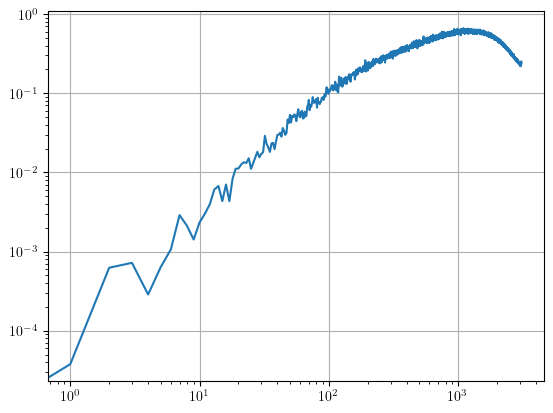

In [4]:
import matplotlib.pyplot as pl
ell = np.arange(len(map_cls))
fac = ell*(ell+1)/(2*np.pi)
pl.figure()
pl.plot(ell, 1e12*fac*map_cls)
pl.xscale('log')
pl.yscale('log')
pl.grid()



In [35]:
import pickle as pk
nside = 2048
Ndevices = 8
map_final = np.zeros(12*nside**2, dtype=np.float32)
for jdevice in range(Ndevices-4):
    sdir = '/mnt/home/spandey/ceph/paste_godmax/GODMAX/results/halfdome/'
    save_map_fname = f'{sdir}/allmaps_sim_B12_nside{nside}_split{jdevice}of{Ndevices}.pkl'
    with open(save_map_fname, 'rb') as f:
        data = pk.load(f)
        map_final += data['map_ymap']
        print(f"Loaded map from device {jdevice}")
map_cls = hp.anafast(map_final)


Loaded map from device 0
Loaded map from device 1
Loaded map from device 2
Loaded map from device 3


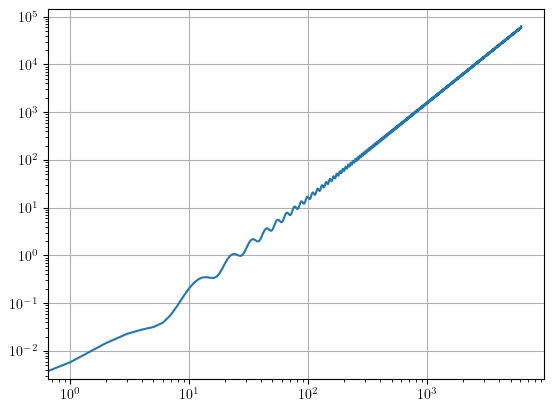

In [34]:
nside = 2048
Ndevices = 8
jdevice = 5
sdir = '/mnt/home/spandey/ceph/paste_godmax/GODMAX/results/halfdome/'
save_map_fname = f'{sdir}/allmaps_sim_B12_nside{nside}_split{jdevice}of{Ndevices}.pkl'
with open(save_map_fname, 'rb') as f:
    data = pk.load(f)
    map_final = data['map_ymap']

map_cls = hp.anafast(map_final)
import matplotlib.pyplot as pl
ell = np.arange(len(map_cls))
fac = ell*(ell+1)/(2*np.pi)
pl.figure()
pl.plot(ell, 1e12*fac*map_cls)
pl.xscale('log')
pl.yscale('log')
pl.grid()





Text(0, 0.5, '$\\ell(\\ell+1)C_\\ell^{yy}/(2\\pi)$')

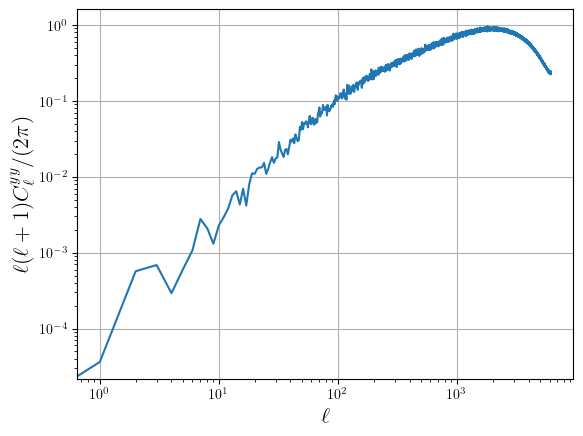

In [43]:
import matplotlib.pyplot as pl
ell = np.arange(len(map_cls))
fac = ell*(ell+1)/(2*np.pi)
pl.figure()
pl.plot(ell, 1e12*fac*map_cls)
pl.xscale('log')
pl.yscale('log')
pl.grid()
pl.xlabel(r'$\ell$', fontsize=16)
pl.ylabel(r"$\ell(\ell+1)C_\ell^{yy}/(2\pi)$", fontsize=16)



In [37]:
fname = '/mnt/ceph/users/abayer/fastpm/halfdome/stampede2_3750Mpch_6144cube/final_res/halos/lightcone_100.hdf5'
with h5.File(fname, 'r') as f:
    # print(f.keys())
    M200c_all = f['halo_mass_m200c'][:]
    z_all = f['redshift'][:]
    pos = f['Position'][:]
    v_all = f['Velocity'][:]

ra_all, dec_all = hp.vec2ang(pos, lonlat=True)

# get the line of sight velocity:
vlos_all = np.sum(v_all * hp.ang2vec(ra_all, dec_all, lonlat=True), axis=1)

zmax = 2.0
indsel = np.where((z_all>0.001) & (z_all<zmax) & (M200c_all<4e16) & (M200c_all>(10**13.0)))[0]

# zmax = 1.0
# indsel = np.where((z_all>0.001) & (z_all<zmax) & (M200c_all<4e16) & (M200c_all>(10**13.7)))[0]


argsort = np.flip(np.argsort(M200c_all[indsel]))
Nsel = (len(argsort) // Ndevices) * Ndevices
argsort = argsort[:Nsel]




In [44]:
jdevice = 4
argsort_split = split_array_power_ratio(argsort, Ndevices)
argsort_here = argsort_split[jdevice]
final_indices = indsel[argsort_here]



(13.2, 15.5)

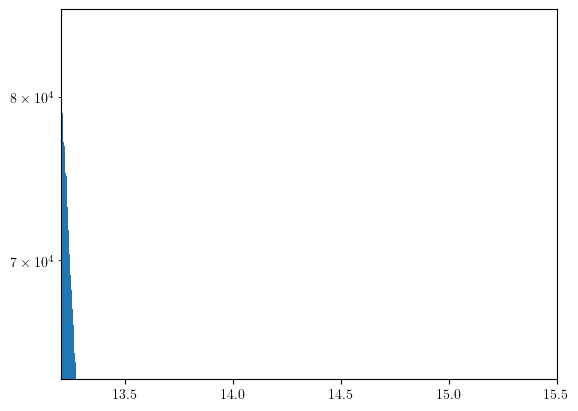

In [47]:
pl.figure()
_ = pl.hist(np.log10(M200c_all[final_indices]), bins=50)
pl.yscale('log')
pl.xlim(13.2, 15.5)



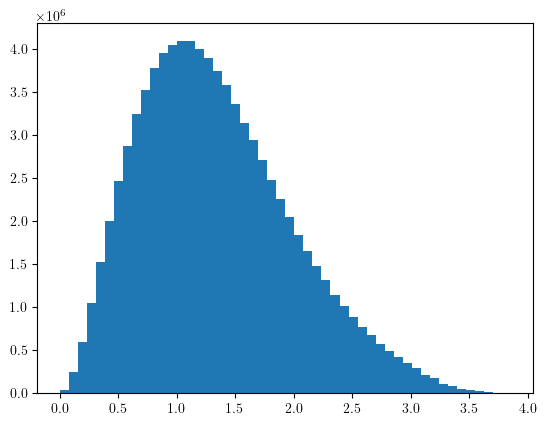

In [7]:
pl.figure()
_ = pl.hist(z_all, bins=50)
